In [109]:
import torch 
from torch import nn
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import math
import random
from sklearn.decomposition import PCA

# prepare data

In [86]:
df = pd.read_csv("./data/archive/mnist_train.csv")

In [87]:
df.head()

,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## labels

In [88]:
train_labels = np.array(df['label'])
train_labels = np.reshape(train_labels, (train_labels.shape[0], 1))

In [89]:
type(train_labels[0])

numpy.ndarray

In [90]:
train_labels

array([[5],
       [0],
       [4],
       ...,
       [5],
       [6],
       [8]], shape=(60000, 1))

In [91]:
df.iloc[0]

label    5
1x1      0
1x2      0
1x3      0
1x4      0
        ..
28x24    0
28x25    0
28x26    0
28x27    0
28x28    0
Name: 0, Length: 785, dtype: int64

In [92]:
type(df.iloc[0])

pandas.core.series.Series

## images

In [93]:
train_images = []
for i in range(len(df)):
    col = df.iloc[i]
    pixel_vals = col[1:].to_list()
    train_images.append(pixel_vals)

In [94]:
train_images = np.array(train_images)

In [95]:
train_images.shape

(60000, 784)

In [96]:
train_images

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(60000, 784))

In [97]:
train_images = train_images / 255.0 # normalize

## plot image

In [98]:
DIM = int(math.sqrt(train_images.shape[1]))
train_images_2d = np.reshape(train_images, (train_images.shape[0], DIM, DIM))

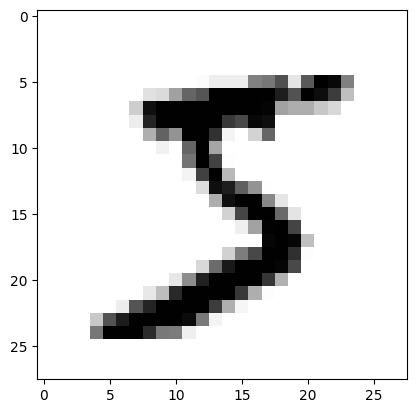

In [99]:
plt.imshow(train_images_2d[0], cmap='binary')
plt.show()

# build autoencoder

In [100]:
CODING_DIM = 64

## define encoder

In [101]:
encoder = nn.Sequential(
    nn.Linear(784, 256),
    nn.ReLU(),
    nn.Linear(256, 128),
    nn.ReLU(),
    nn.Linear(128, CODING_DIM)
)

## define decoder

In [102]:
decoder = nn.Sequential(
    nn.Linear(CODING_DIM, 128),
    nn.ReLU(),
    nn.Linear(128, 256),
    nn.ReLU(),
    nn.Linear(256, 784),
    nn.Sigmoid()
)

## autoencoder model

In [103]:
class AutoEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, x):
        h = self.encoder(x)
        r = self.decoder(h)
        return r

In [104]:
autoencoder = AutoEncoder()

# model configurations

In [105]:
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(autoencoder.parameters())

# training

In [106]:
BATCH_SIZE = 64
EPOCHS = 10

for epoch in range(EPOCHS):
    running_loss = 0
    for i in range(0, len(train_images), BATCH_SIZE):
        optimizer.zero_grad()

        inputs = torch.Tensor(train_images[i:i+BATCH_SIZE])
        outputs = autoencoder(inputs)

        loss = loss_fn(outputs, inputs)
        loss.backward()

        optimizer.step()

        running_loss += loss.item() * inputs.size(0)

    print(f'epoch: {epoch+1}, loss: {running_loss / len(train_images):.3f}')

epoch: 1, loss: 0.044
epoch: 2, loss: 0.020
epoch: 3, loss: 0.015
epoch: 4, loss: 0.012
epoch: 5, loss: 0.011
epoch: 6, loss: 0.010
epoch: 7, loss: 0.009
epoch: 8, loss: 0.008
epoch: 9, loss: 0.008
epoch: 10, loss: 0.007


# visualize reconstruction

In [107]:
sample_img = torch.Tensor(train_images[0])
sample_input = sample_img.unsqueeze(0)

reconstructed = autoencoder(sample_input)
reconstructed_img = reconstructed.view(28, 28).detach().numpy()

original_img = train_images_2d[0]

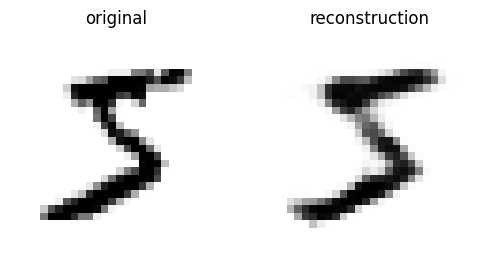

In [108]:
plt.figure(figsize=(6,3))

plt.subplot(1,2,1)
plt.imshow(original_img, cmap='binary')
plt.title(f'original')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(reconstructed_img, cmap='binary')
plt.title('reconstruction')
plt.axis('off')

plt.show()

# visualize latent space

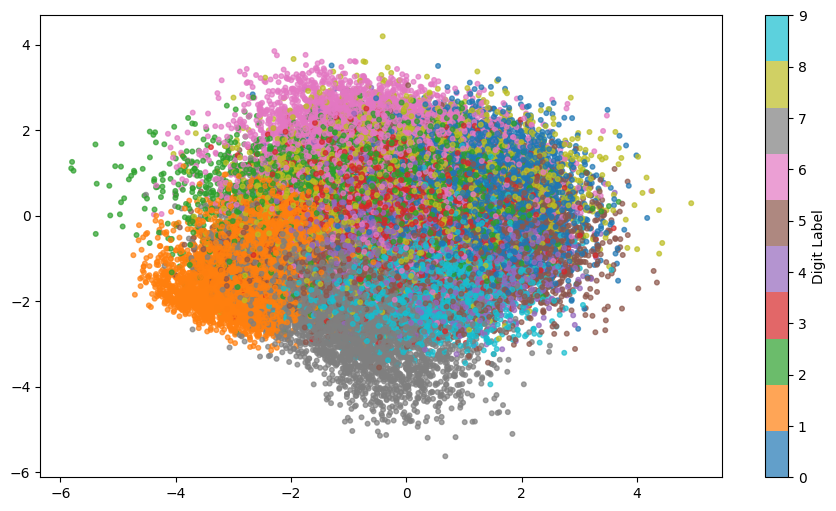

In [120]:
images_tensor = torch.Tensor(train_images)

autoencoder.eval()

with torch.no_grad():
    latent_vectors = autoencoder.encoder(images_tensor)

latent_vectors = latent_vectors.numpy()

plt.figure(figsize=(11,6))
plt.scatter(latent_vectors[:,0], latent_vectors[:,1], c=train_labels, cmap='tab10', alpha=0.7, s=11)
plt.colorbar(label='Digit Label')
plt.show()